In [1]:
import os
os.chdir('../')

In [2]:
import torch
from pathlib import Path

def load_feats(d, k="inception_feature"):
    xs=[]
    for p in Path(d).rglob("*.pt"):
        v = torch.load(p, map_location="cpu")
        v = v[k] if isinstance(v, dict) else v
        xs.append(v.view(-1, 2048).float())
    return torch.cat(xs, 0)  # (B, 2048)

@torch.no_grad()
def precision_recall_torch(ref_features, sample_features, k=3, normalize=False, radius_scale=1.0):
    assert ref_features.dim()==2 and sample_features.dim()==2
    assert ref_features.size(1)==sample_features.size(1)
    R, G = ref_features, sample_features
    if normalize:
        R = torch.nn.functional.normalize(R, dim=1)
        G = torch.nn.functional.normalize(G, dim=1)

    def knn_radii(X, k):
        n = X.size(0); k = max(1, min(k, n-1))
        D = torch.cdist(X, X); D.fill_diagonal_(float('inf'))
        return D.kthvalue(k, dim=1).values

    r = knn_radii(R, k) * radius_scale   # 실측 매니폴드 반경
    s = knn_radii(G, k) * radius_scale   # 생성 매니폴드 반경
    D = torch.cdist(R, G)
    precision = (D <= r[:, None]).any(0).float().mean().item()
    recall    = (D <= s[None, :]).any(1).float().mean().item()
    return precision, recall


In [3]:
valid_features = torch.load('/dataset/dit/valid_feats.pt')['features']
valid_features.shape

torch.Size([10000, 2048])

  0%|          | 0/5 [00:00<?, ?it/s]

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_0/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_1/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_2/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_3/


...

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_16/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_17/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_18/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_19/


100%|██████████| 20/20 [02:21<00:00,  7.08s/it]


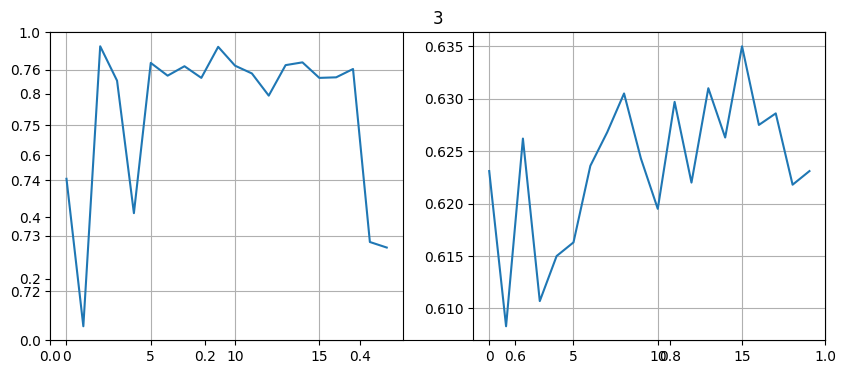

 20%|██        | 1/5 [02:21<09:26, 141.69s/it]

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_0/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_1/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_2/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_3/


...

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_16/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_17/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_18/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_19/


100%|██████████| 20/20 [01:26<00:00,  4.34s/it]


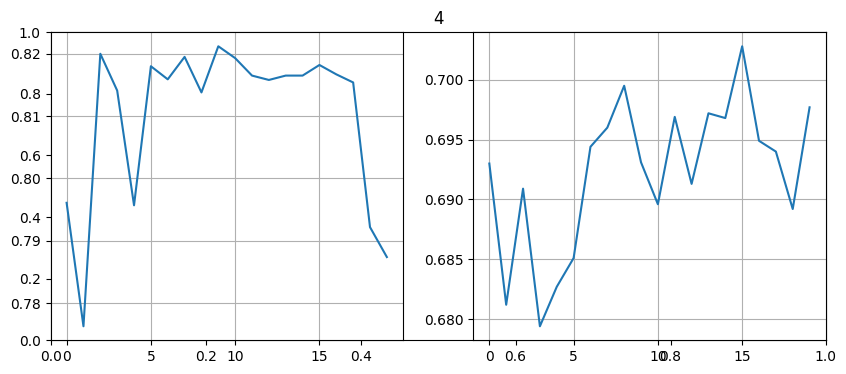

 40%|████      | 2/5 [03:48<05:28, 109.54s/it]

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_0/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_1/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_2/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_3/


...

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_16/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_17/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_18/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_19/


100%|██████████| 20/20 [01:27<00:00,  4.35s/it]


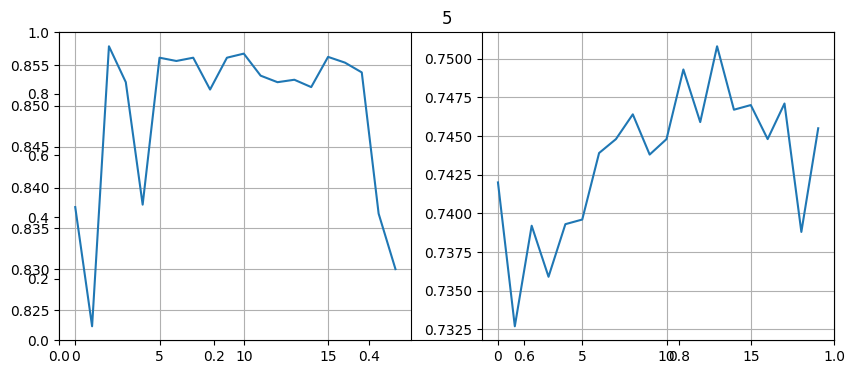

 60%|██████    | 3/5 [05:15<03:18, 99.35s/it] 

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_0/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_1/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_2/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_3/


...

samplings/GMDiT/1.4/3/Dual-Solver/10000/which_12/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_13/


samplings/GMDiT/1.4/3/Dual-Solver/10000/which_14/


 60%|██████    | 3/5 [06:18<04:12, 126.12s/it]


KeyboardInterrupt: 

In [5]:
from tqdm import tqdm
import matplotlib.pyplot as plt

precisions = {}
recalls = {}
for k in tqdm([3, 4, 5, 6, 7]):
    precisions[k] = []
    recalls[k] = []
    for i in tqdm(range(0, 20)):
        dir = f"samplings/GMDiT/1.4/3/Dual-Solver/10000/which_{i}/"
        if not os.path.exists(dir):
            continue
        print(dir)
            
        sample_features = load_feats(dir)
        #print('sample_features')
        precision, recall = precision_recall_torch(valid_features, sample_features, k=k)
        #print('precision, recall')
        precisions[k].append(precision)
        recalls[k].append(recall)

    plt.figure(figsize=[10, 4])
    plt.title(f"{k}")
    plt.subplot(1, 2, 1)
    plt.grid()
    plt.plot(precisions[k])
    plt.subplot(1, 2, 2)
    plt.plot(recalls[k])
    plt.grid()
    plt.show()
        

100%|██████████| 20/20 [01:27<00:00,  4.39s/it]


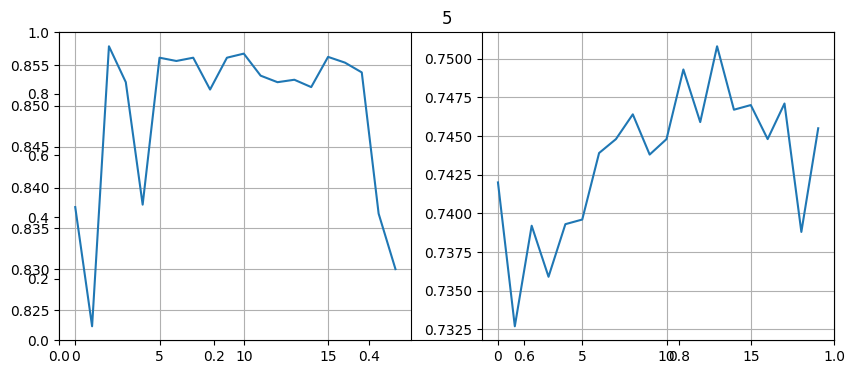

In [4]:
from tqdm import tqdm
import matplotlib.pyplot as plt

precisions = {}
recalls = {}
k = 5
precisions[k] = []
recalls[k] = []
for i in tqdm(range(0, 20)):
    dir = f"samplings/GMDiT/1.4/3/Dual-Solver/10000/which_{i}/"
    if not os.path.exists(dir):
        continue
        
    sample_features = load_feats(dir)
    #print('sample_features')
    precision, recall = precision_recall_torch(valid_features, sample_features, k=k)
    #print('precision, recall')
    precisions[k].append(precision)
    recalls[k].append(recall)

plt.figure(figsize=[10, 4])
plt.title(f"{k}")
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(precisions[k])
plt.subplot(1, 2, 2)
plt.plot(recalls[k])
plt.grid()
plt.show()
    